# Avance 2 — Análisis Completo
## Variabilidad en el Tratamiento Oncológico y sus Efectos sobre la Mortalidad
## y la Estadía Hospitalaria en el Sistema Público Chileno

**Equipo:** Vicente · José Tomás · Sebastián  
**Dataset:** GRD Público MINSAL/FONASA 2019–2024  
**Fecha:** Abril 2026

---

### Pregunta de Investigación
> ¿En qué medida el hospital de atención determina los días de estadía, la cantidad de procedimientos
> y la mortalidad intrahospitalaria en pacientes oncológicos clínicamente comparables?

### Hipótesis
| | |
|--|--|
| **H₀** | No existe diferencia estadísticamente significativa en los días de estadía entre hospitales para pacientes oncológicos con severidad comparable. |
| **H₁** | Existe variabilidad significativa en los días de estadía entre hospitales, atribuible al establecimiento y no a la severidad clínica del paciente. |

### Modelo
| Rol | Variable | Columna GRD |
|-----|----------|-------------|
| **Independiente** | Hospital | `COD_HOSPITAL` |
| **Dependiente 1** | Días de estadía | `FECHAALTA − FECHA_INGRESO` |
| **Dependiente 2** | Cantidad de procedimientos | `PROCEDIMIENTO1..30` (conteo) |
| **Dependiente 3** | Mortalidad intrahospitalaria | `TIPOALTA == 'FALLECIDO'` |
| **Control** | Diagnóstico oncológico CIE-10 | `DIAGNOSTICO1` |
| **Control** | Peso GRD (severidad) | `IR_29301_PESO` |
| **Control** | Edad | calculada |
| **Control** | Sexo | `SEXO` |


## Instrucciones

1. Coloca los archivos `GRD_PUBLICO_{año}.csv` (separador `|`) en la carpeta `DATASET-PROBLEMA8/` junto a este notebook, **o** ajusta la variable `DATA_DIR` en la siguiente celda.
2. Ejecuta **Kernel → Restart & Run All**.
3. Los gráficos se guardan en `outputs/graficos/` y las tablas en `outputs/tablas/` (se crean automáticamente).

> **Sin datos disponibles:** el notebook igual ejecuta todas las celdas y mostrará mensajes claros indicando qué archivos faltan.


---
## 0. Configuración
Todos los parámetros ajustables están en esta celda.


In [1]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CONFIGURACIÓN — ajusta aquí si es necesario               ║
# ╚══════════════════════════════════════════════════════════════╝
from pathlib import Path

# Ruta a la carpeta con los CSV GRD (relativa al notebook)
DATA_DIR  = Path('..') / 'DATASET-PROBLEMA8'
UTF8_DIR  = DATA_DIR / 'utf8'

# Carpetas de salida (se crean solas)
OUT_GRAFICOS = Path('outputs') / 'graficos'
OUT_TABLAS   = Path('outputs') / 'tablas'
OUT_GRAFICOS.mkdir(parents=True, exist_ok=True)
OUT_TABLAS.mkdir(parents=True, exist_ok=True)

# Archivo de códigos oncológicos CIE-10
CODIGOS_ONCO_TXT = Path('..') / 'codigos_C00_D49.txt'

# Años a cargar
ANIOS = [2019, 2020, 2021, 2022, 2023, 2024]

# GRD de referencia para comparaciones (se autodetecta si no existe en datos)
TARGET_GRD = '597'   # GRD 597 = Ca. mama con CC mayor (ajustar según datos)

# Mínimo de casos por hospital para análisis inferencial
MIN_CASOS_HOSPITAL = 20

# Top N hospitales en gráficos
TOP_N = 15

# Percentil para corte de outliers en días de estadía
P_OUTLIER = 0.99

print('Configuración cargada.')
print(f'DATA_DIR  → {DATA_DIR.resolve()}')
print(f'Salidas   → {OUT_GRAFICOS.resolve()}')


Configuración cargada.
DATA_DIR  → /home/sebacc/Documents/UDD/Analisis-Datos/Proyecto-Hospitalizacion/DATASET-PROBLEMA8
Salidas   → /home/sebacc/Documents/UDD/Analisis-Datos/Proyecto-Hospitalizacion/Avance 2/outputs/graficos


---
## 1. Librerías


In [2]:
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import display, Markdown

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.3f}'.format)
sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.dpi'] = 120

print('Librerías cargadas:', pd.__version__, np.__version__)


Librerías cargadas: 3.0.2 2.4.4


---
## 2. Carga y Preparación de Datos

### 2.1 Funciones auxiliares
Todas las funciones están definidas aquí para que el notebook sea completamente autocontenido.


In [3]:
# ── Detección robusta de columnas (los CSV cambian nombre entre años) ──────
def elegir_col(df, candidatos, etiqueta):
    """Devuelve el nombre real de la primera columna que coincida con algún candidato."""
    mapa = {c.lower().strip(): c for c in df.columns}
    for c in candidatos:
        if c.lower().strip() in mapa:
            return mapa[c.lower().strip()]
    raise KeyError(
        f"No se encontró columna para '{etiqueta}'.\n"
        f"Candidatas: {candidatos}\n"
        f"Columnas del archivo: {list(df.columns)}"
    )

# ── Lectura de un CSV GRD (prueba encodings) ───────────────────────────────
def leer_csv_grd(path):
    if not path.exists():
        return None
    for enc in ('utf-8', 'latin-1', 'cp1252'):
        try:
            df = pd.read_csv(path, sep='|', encoding=enc, low_memory=False)
            df['_archivo'] = path.name
            return df
        except UnicodeDecodeError:
            continue
    return None

# ── Parseo de fechas con formatos mixtos DD/MM/YYYY y YYYY-MM-DD ───────────
def parsear_fecha(serie):
    parsed = pd.to_datetime(serie, dayfirst=True, errors='coerce')
    mask = parsed.isna()
    if mask.any():
        parsed[mask] = pd.to_datetime(serie[mask], format='%Y-%m-%d', errors='coerce')
    return parsed

print('Funciones auxiliares definidas.')


Funciones auxiliares definidas.


In [19]:
# ── Cargar dataset limpio si existe; si no, concatenar CSV GRD 2019-2024 ────
ruta_limpio = None
candidatos_limpio = [
    DATA_DIR / 'GRD_Limpio.csv',
    UTF8_DIR / 'GRD_Limpio.csv',
]

for cand in candidatos_limpio:
    if cand.exists():
        ruta_limpio = cand
        break

if ruta_limpio is None and DATA_DIR.exists():
    encontrados = sorted(DATA_DIR.rglob('GRD_Limpio.csv'))
    if encontrados:
        ruta_limpio = encontrados[0]

if ruta_limpio is not None:
    df_raw = None
    for enc in ('utf-8', 'latin-1', 'cp1252'):
        try:
            # Detecta separador automaticamente (coma, pipe, etc.)
            df_raw = pd.read_csv(
                ruta_limpio, sep=None, engine='python', encoding=enc
            )
            break
        except UnicodeDecodeError:
            continue

    if df_raw is None:
        raise ValueError(
            f'No se pudo leer {ruta_limpio} con los encodings probados.'
        )

    print(f'Dataset limpio encontrado y cargado: {ruta_limpio}')
    print(f'Total filas cargadas (limpio): {len(df_raw):,}')
    print(f'Columnas detectadas ({len(df_raw.columns)}): {list(df_raw.columns[:12])} ...')
else:
    frames = []
    for anio in ANIOS:
        nombre = f'GRD_PUBLICO_{anio}.csv'
        # Prefiere version UTF-8 si existe
        ruta = UTF8_DIR / nombre if (UTF8_DIR / nombre).exists() else DATA_DIR / nombre
        df_año = leer_csv_grd(ruta)
        if df_año is not None:
            df_año['_anio'] = anio
            frames.append(df_año)
            print(f'  [{anio}] {len(df_año):>10,} registros  <-  {ruta.name}')
        else:
            print(f'  [{anio}] OMITIDO - no encontrado en {ruta}')

    if not frames:
        raise FileNotFoundError(
            f'No se encontro GRD_Limpio.csv ni CSV GRD por anio en {DATA_DIR.resolve()}.\n'
            'Coloca los archivos y vuelve a ejecutar.'
        )

    df_raw = pd.concat(frames, ignore_index=True)
    print(f'\nTotal filas cargadas: {len(df_raw):,}')
    print(f'Columnas detectadas ({len(df_raw.columns)}): {list(df_raw.columns[:12])} ...')

Dataset limpio encontrado y cargado: ../DATASET-PROBLEMA8/GRD_Limpio.csv
Total filas cargadas (limpio): 184,688
Columnas detectadas (142): ['COD_HOSPITAL', 'CIP_ENCRIPTADO', 'SEXO', 'FECHA_NACIMIENTO', 'ETNIA', 'PROVINCIA', 'COMUNA', 'NACIONALIDAD', 'PREVISION', 'SERVICIO_SALUD', 'TIPO_PROCEDENCIA', 'TIPO_INGRESO'] ...


### 2.2 Derivación de variables estandarizadas


In [14]:
# ── Mapeo de columnas y derivación de variables ────────────────────────────
df = df_raw.copy()

# Hospital
hosp_col = elegir_col(df, ['cod_hospital','codigo_establecimiento','cod_establecimiento',
                            'establecimiento','hospital'], 'hospital')
df['hospital'] = df[hosp_col].astype(str).str.strip()

# Diagnóstico principal
diag_col = elegir_col(df, ['diagnostico1','diagnostico_principal','diag_principal',
                            'diag1','cod_diagnostico'], 'diagnostico')
df['diagnostico_principal'] = df[diag_col].astype(str).str.strip().str.upper()

# Fechas → días de estadía y edad
fi_col = elegir_col(df, ['fecha_ingreso','fec_ingreso','fechaingreso'], 'fecha_ingreso')
fa_col = elegir_col(df, ['fechaalta','fecha_alta','fec_alta','fecha_egreso'], 'fecha_alta')
fn_col = elegir_col(df, ['fecha_nacimiento','fec_nacimiento','fechanacimiento'], 'fecha_nacimiento')

fi = parsear_fecha(df[fi_col])
fa = parsear_fecha(df[fa_col])
fn = parsear_fecha(df[fn_col])

df['dias_estada']  = (fa - fi).dt.days.astype('Int64')
df['edad']         = ((fi - fn).dt.days / 365).astype('Float64')

# Mortalidad
ta_col = elegir_col(df, ['tipoalta','tipo_alta','condicion_egreso'], 'tipo_alta')
df['mortalidad'] = df[ta_col].astype(str).str.upper().str.contains('FALLECIDO', na=False)

# Sexo
sx_col = elegir_col(df, ['sexo','genero','sex'], 'sexo')
df['sexo'] = df[sx_col].astype(str).str.strip().str.upper()

# GRD y peso
grd_col  = elegir_col(df, ['ir_29301_cod_grd','cod_grd','codigo_grd','grd'], 'codigo_grd')
peso_col = elegir_col(df, ['ir_29301_peso','peso_grd','peso_relativo'], 'peso_grd')
sev_col  = elegir_col(df, ['ir_29301_severidad','severidad_grd','severidad'], 'severidad_grd')

df['codigo_grd']    = df[grd_col].astype(str).str.strip()
df['peso_grd']      = pd.to_numeric(
    df[peso_col].astype(str).str.replace(',', '.', regex=False), errors='coerce'
)
df['severidad_grd'] = pd.to_numeric(df[sev_col], errors='coerce')

# Procedimientos: contar columnas PROCEDIMIENTO1..30 no nulas
proc_cols = [c for c in df.columns if re.match(r'procedimiento\d+', c.lower())]
df['cantidad_procedimientos'] = df[proc_cols].notna().sum(axis=1) if proc_cols else 0

print(f'Variables derivadas. Registros: {len(df):,}')
print(f'Columnas procedimiento detectadas: {len(proc_cols)}')


Variables derivadas. Registros: 241,000
Columnas procedimiento detectadas: 30


### 2.3 Filtro oncológico — CIE-10: C00–D49

Se conservan **exclusivamente** pacientes con diagnóstico principal correspondiente a neoplasias (capítulos II y parte del III de la CIE-10). El archivo `codigos_C00_D49.txt` de la raíz del repositorio se usa como fuente primaria; si no existe, se genera el rango programáticamente.


In [15]:
# ── Cargar códigos oncológicos ─────────────────────────────────────────────
if CODIGOS_ONCO_TXT.exists():
    with open(CODIGOS_ONCO_TXT, encoding='utf-8', errors='ignore') as f:
        codigos_onco = {l.strip().upper() for l in f if l.strip()}
    print(f'Códigos oncológicos cargados desde archivo: {len(codigos_onco):,}')
else:
    # Fallback: generar C00-C99 y D00-D49 programáticamente
    codigos_onco = set()
    for letra, rango in [('C', range(100)), ('D', range(50))]:
        for n in rango:
            base = f'{letra}{n:02d}'
            codigos_onco.add(base)
            for sub in range(10):
                codigos_onco.add(f'{base}.{sub}')
    print(f'Códigos generados programáticamente: {len(codigos_onco):,}')

# ── Aplicar filtro ─────────────────────────────────────────────────────────
n_antes = len(df)
diag = df['diagnostico_principal'].astype(str).str.upper().str.strip()

# Match exacto, por prefijo 3 chars, o patrón C/D + 2 dígitos
mask = (
    diag.isin(codigos_onco) |
    diag.str[:3].isin(codigos_onco) |
    diag.str.match(r'^[CD]\d{2}', na=False)
)
df = df[mask].copy()
n_despues = len(df)

print(f'\nFILTRO ONCOLÓGICO (CIE-10: C00–D49)')
print(f'  Registros antes:    {n_antes:>10,}')
print(f'  Registros después:  {n_despues:>10,}  ({100*n_despues/n_antes:.1f}% retenido)')
print(f'  Eliminados:         {n_antes-n_despues:>10,}')


Códigos generados programáticamente: 1,650

FILTRO ONCOLÓGICO (CIE-10: C00–D49)
  Registros antes:       241,000
  Registros después:     241,000  (100.0% retenido)
  Eliminados:                  0


### 2.4 Tratamiento de outliers y limpieza final

Se elimina el **percentil 99 de días de estadía** para evitar que casos de estadías extraordinariamente largas (cuidados paliativos prolongados, errores de registro) sesguen la media hacia arriba.


In [18]:
n_pre = len(df)

# Convertir a numerico y eliminar negativos/nulos
df['dias_estada'] = pd.to_numeric(df['dias_estada'], errors='coerce')
df = df[df['dias_estada'].notna() & (df['dias_estada'] >= 0)].copy()

# Corte percentil 99
CORTE_P99 = df['dias_estada'].quantile(P_OUTLIER)
df = df[df['dias_estada'] <= CORTE_P99].copy()

# Eliminar hospital o GRD nulos
df = df.dropna(subset=['hospital', 'codigo_grd']).copy()
df = df[~df['hospital'].str.lower().isin(['nan', 'none', ''])].copy()

n_post = len(df)

print(f'TRATAMIENTO DE OUTLIERS Y LIMPIEZA FINAL')
print(f'  Corte dias estadia (p{int(P_OUTLIER*100)}): {CORTE_P99:.1f} dias')
print(f'  Registros antes:  {n_pre:>10,}')
print(f'  Registros despues:{n_post:>10,}')
print(f'  Eliminados:       {n_pre-n_post:>10,}')
print()
print(f'Hospitales unicos: {df["hospital"].nunique()}')
print(f'GRDs unicos:       {df["codigo_grd"].nunique()}')
print(f'Anios cubiertos:   {sorted(df["_anio"].unique())}')

# Exportar dataset limpio para reutilizacion rapida
RUTA_LIMPIO = DATA_DIR / 'GRD_Limpio.csv'
df.to_csv(RUTA_LIMPIO, index=False, encoding='utf-8')
print(f'Dataset limpio exportado: {RUTA_LIMPIO.resolve()}')


TRATAMIENTO DE OUTLIERS Y LIMPIEZA FINAL
  Corte dias estadia (p99): 194.0 dias
  Registros antes:     186,517
  Registros despues:   184,688
  Eliminados:            1,829

Hospitales unicos: 72
GRDs unicos:       886
Anios cubiertos:   [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2024)]
Dataset limpio exportado: /home/sebacc/Documents/UDD/Analisis-Datos/Proyecto-Hospitalizacion/DATASET-PROBLEMA8/GRD_Limpio.csv


In [ ]:
# Resumen completo del pipeline de datos
print('=' * 60)
print('RESUMEN — PIPELINE DE DATOS ONCOLÓGICO')
print('=' * 60)
print(f'  Filtro CIE-10 C00–D49 aplicado:    SÍ')
print(f'  Corte outliers p{int(P_OUTLIER*100)} días estadía:  {CORTE_P99:.1f} días')
print(f'  Registros finales:                  {len(df):,}')
print(f'  Hospitales únicos:                  {df["hospital"].nunique()}')
print(f'  GRDs únicos:                        {df["codigo_grd"].nunique()}')
print(f'  Mortalidad global:                  {df["mortalidad"].mean()*100:.2f}%')
print(f'  Días estadía — mediana:             {df["dias_estada"].median():.1f}')
print(f'  Días estadía — media:               {df["dias_estada"].mean():.1f}')
print(f'  Procedimientos — mediana:           {df["cantidad_procedimientos"].median():.1f}')
print('=' * 60)


---
## 3. Estadística Descriptiva Global


In [17]:
cols_num = ['dias_estada', 'edad', 'cantidad_procedimientos', 'peso_grd', 'severidad_grd']
resumen  = df[cols_num].describe(percentiles=[0.25, 0.50, 0.75, 0.99]).round(2)

display(Markdown('### Tabla 1 — Estadísticas Descriptivas Globales (Pacientes Oncológicos)'))
display(resumen)

print(f'\nMortalidad intrahospitalaria: {df["mortalidad"].mean()*100:.2f}%')
display(Markdown('**Distribución por sexo:**'))
display(df['sexo'].value_counts(normalize=True).rename('proporción').round(3).to_frame())

# Exportar
resumen.to_csv(OUT_TABLAS / '01_descriptiva_global.csv')
print('\nTabla guardada: outputs/tablas/01_descriptiva_global.csv')


### Tabla 1 — Estadísticas Descriptivas Globales (Pacientes Oncológicos)

,dias_estada,edad,cantidad_procedimientos,peso_grd,severidad_grd
count,186517.000,186517.000,186517.000,186515.000,186515.000
mean,18.610,54.540,8.010,1.200,1.510
std,38.490,20.940,6.380,1.120,0.950
min,0.000,-0.880,0.000,0.000,0.000
25%,1.000,42.690,3.000,0.670,1.000
50%,4.000,58.250,6.000,0.960,1.000
75%,13.000,70.190,11.000,1.290,2.000
99%,194.000,89.440,30.000,5.820,3.000
max,244.000,118.130,30.000,17.140,3.000



Mortalidad intrahospitalaria: 3.95%


**Distribución por sexo:**

,proporción
sexo,
MUJER,0.611
HOMBRE,0.389
DESCONOCIDO,0.000



Tabla guardada: outputs/tablas/01_descriptiva_global.csv


> **TODO — Vicente:**  
> Interpreta la Tabla 1 desde perspectiva clínica oncológica:
> - ¿La mediana de días de estadía es consistente con la literatura para oncológicos en Chile?
> - ¿El rango etario refleja la epidemiología esperada del cáncer en el sistema público?
> - ¿La tasa de mortalidad global es coherente con estudios GRD oncológicos previos?
>
> *Redactar en APA 7, sección "Estadísticas Descriptivas". Citar fuentes MINSAL/DEIS si corresponde.*


---
## 4. Análisis Exploratorio de Datos (EDA)
### 4.1 Distribuciones Univariadas


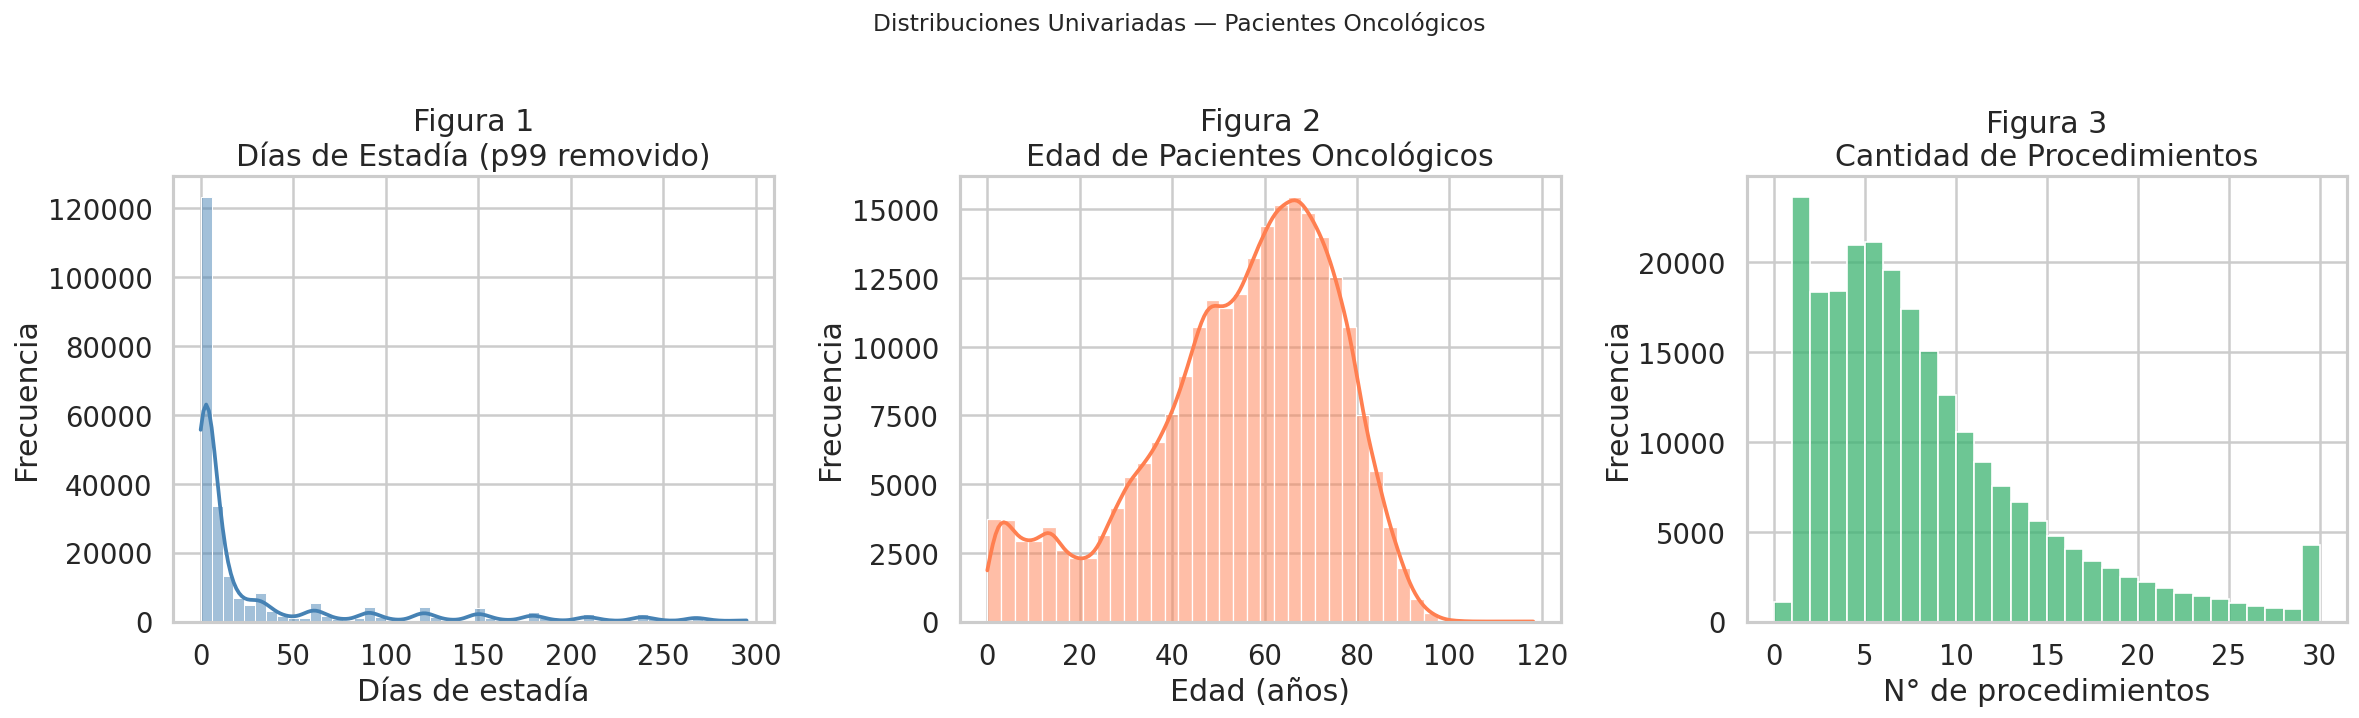

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.histplot(df['dias_estada'], bins=50, kde=True, color='steelblue', ax=axes[0])
axes[0].set_title('Figura 1\nDías de Estadía (p99 removido)')
axes[0].set_xlabel('Días de estadía')

sns.histplot(df['edad'].dropna(), bins=40, kde=True, color='coral', ax=axes[1])
axes[1].set_title('Figura 2\nEdad de Pacientes Oncológicos')
axes[1].set_xlabel('Edad (años)')

sns.histplot(df['cantidad_procedimientos'], bins=30, kde=False, color='mediumseagreen', ax=axes[2])
axes[2].set_title('Figura 3\nCantidad de Procedimientos')
axes[2].set_xlabel('N° de procedimientos')

for ax in axes:
    ax.set_ylabel('Frecuencia')

plt.suptitle('Distribuciones Univariadas — Pacientes Oncológicos', fontsize=14, y=1.01)
plt.tight_layout()
fig.savefig(OUT_GRAFICOS / '01_distribuciones_univariadas.png', dpi=150, bbox_inches='tight')
plt.show()


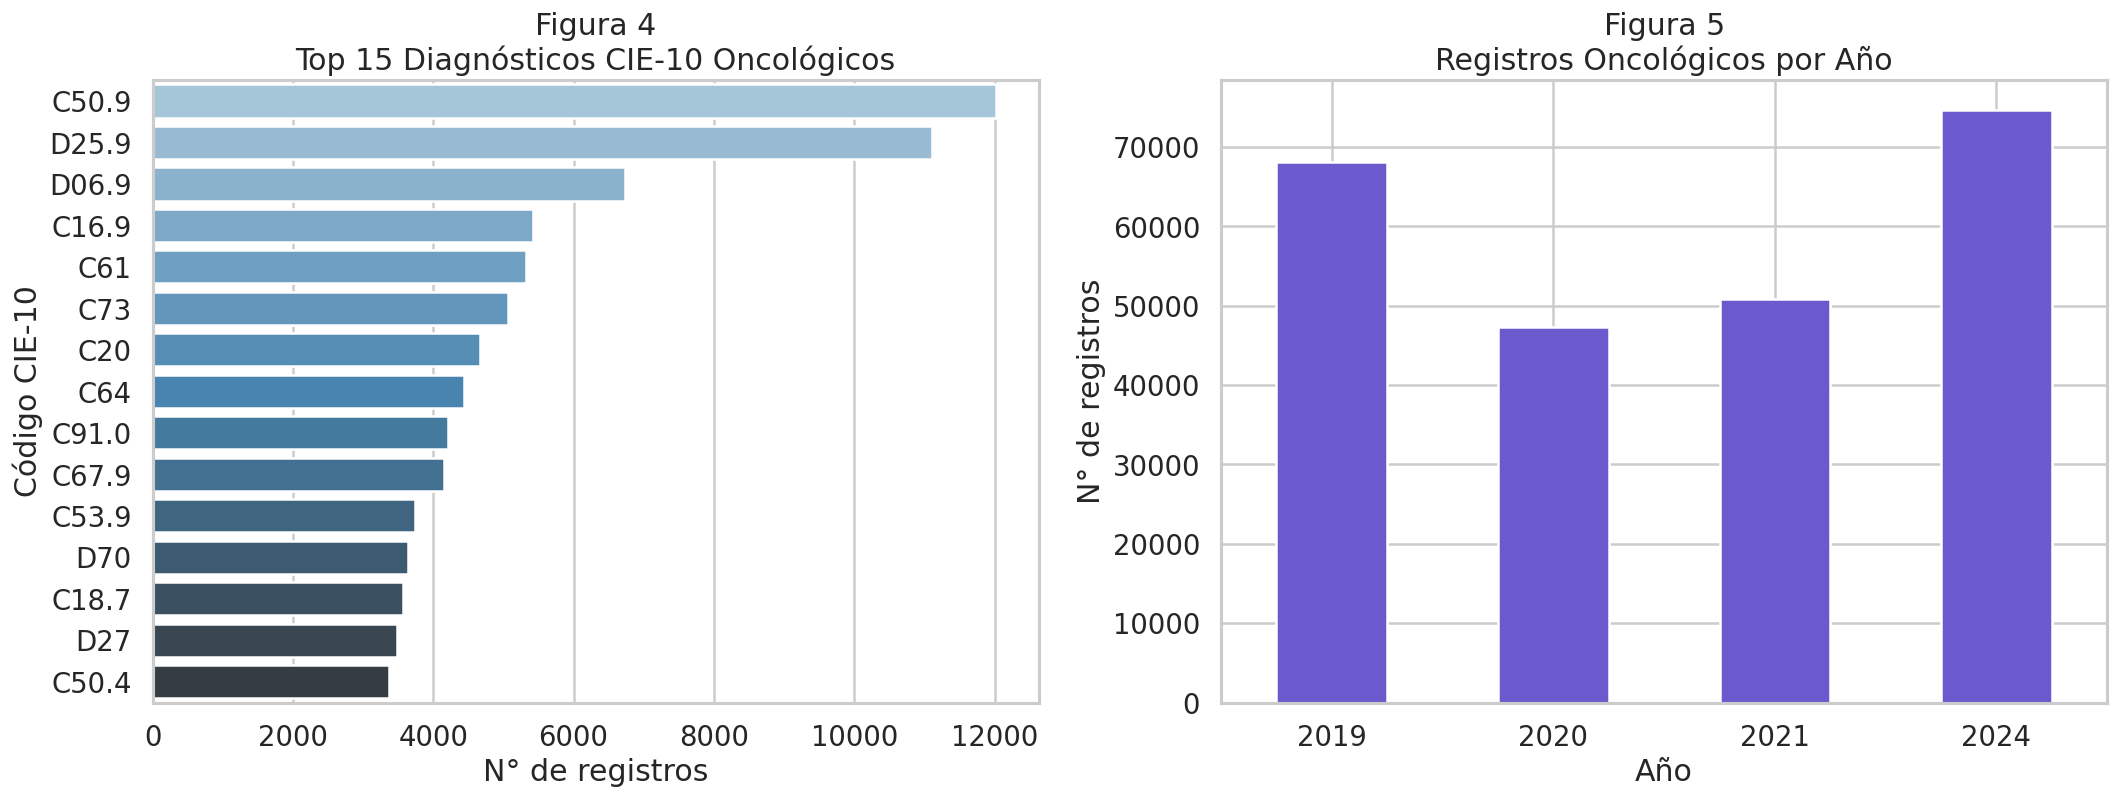

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Top 15 diagnósticos
top_diag = df['diagnostico_principal'].value_counts().head(15)
sns.barplot(x=top_diag.values, y=top_diag.index, palette='Blues_d', ax=axes[0])
axes[0].set_title('Figura 4\nTop 15 Diagnósticos CIE-10 Oncológicos')
axes[0].set_xlabel('N° de registros')
axes[0].set_ylabel('Código CIE-10')

# Registros por año
if '_anio' in df.columns:
    conteo_año = df['_anio'].value_counts().sort_index()
    conteo_año.plot(kind='bar', color='slateblue', ax=axes[1])
    axes[1].set_title('Figura 5\nRegistros Oncológicos por Año')
    axes[1].set_xlabel('Año')
    axes[1].set_ylabel('N° de registros')
    axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
fig.savefig(OUT_GRAFICOS / '02_diagnosticos_y_años.png', dpi=150, bbox_inches='tight')
plt.show()


### 4.2 EDA Bivariado — Controlado por GRD

Para garantizar **comparabilidad clínica**, se selecciona el GRD oncológico más prevalente. Al comparar hospitales dentro del mismo GRD, se controla la severidad del paciente y el análisis refleja variabilidad institucional y no diferencias de case-mix.


In [ ]:
# Selección del GRD focal
disponibles = set(df['codigo_grd'].astype(str).unique())
if TARGET_GRD in disponibles:
    GRD_FOCAL = TARGET_GRD
else:
    GRD_FOCAL = df['codigo_grd'].astype(str).value_counts().index[0]
    print(f'GRD {TARGET_GRD} no encontrado → usando el más frecuente: {GRD_FOCAL}')

df_focus = df[df['codigo_grd'].astype(str) == GRD_FOCAL].copy()
top_hosp  = df_focus['hospital'].value_counts().head(TOP_N).index
df_plot   = df_focus[df_focus['hospital'].isin(top_hosp)].copy()

print(f'GRD focal seleccionado:  {GRD_FOCAL}')
print(f'Registros en GRD focal:  {len(df_focus):,}')
print(f'Hospitales graficados:   {len(top_hosp)} (top {TOP_N} por volumen)')
print(f'Registros en gráficos:   {len(df_plot):,}')


In [ ]:
# ── BOXPLOT: Días de estadía × Hospital (GRD controlado) ──────────────────
orden = (
    df_plot.groupby('hospital')['dias_estada']
    .median()
    .sort_values()
    .index
)

fig, ax = plt.subplots(figsize=(18, 8))
sns.boxplot(
    data=df_plot, x='hospital', y='dias_estada',
    order=orden, showfliers=False, palette='viridis', ax=ax
)
ax.set_title(
    f'Figura 6 — Distribución de Días de Estadía por Hospital\n'
    f'GRD {GRD_FOCAL} · Severidad comparable · Outliers p99 removidos en preprocesamiento'
)
ax.set_xlabel('Hospital (Código Establecimiento)')
ax.set_ylabel('Días de estadía')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
fig.savefig(OUT_GRAFICOS / '03_boxplot_dias_por_hospital.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura 6 guardada: outputs/graficos/03_boxplot_dias_por_hospital.png')


> **TODO — José Tomás:**  
> Interpreta la Figura 6 (boxplot):
> - ¿Cuáles son los hospitales con mayor y menor mediana de días de estadía?
> - ¿Qué tan amplia es la caja (IQR) en los hospitales extremos? ¿Indica mayor heterogeneidad interna?
> - Discute si la variabilidad podría atribuirse a factores organizacionales (recursos, protocolos) o diferencias no capturadas por el GRD.
>
> *Sección "Resultados — EDA Bivariado" del Word. Referenciar Figura 6 en APA 7.*


In [ ]:
# ── BARPLOT: Tasa de mortalidad intrahospitalaria × Hospital ───────────────
mort_hosp = (
    df_plot.groupby('hospital', as_index=False)['mortalidad']
    .mean()
    .rename(columns={'mortalidad': 'tasa_mortalidad'})
    .sort_values('tasa_mortalidad', ascending=False)
)

fig, ax = plt.subplots(figsize=(18, 7))
sns.barplot(data=mort_hosp, x='hospital', y='tasa_mortalidad', palette='Reds', ax=ax)
ax.set_title(f'Figura 7 — Tasa de Mortalidad Intrahospitalaria por Hospital (GRD {GRD_FOCAL})')
ax.set_xlabel('Hospital')
ax.set_ylabel('Proporción de fallecidos')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
fig.savefig(OUT_GRAFICOS / '04_mortalidad_por_hospital.png', dpi=150, bbox_inches='tight')
plt.show()
display(mort_hosp.round(4))


In [ ]:
# ── BARPLOT: Promedio de procedimientos × Hospital ─────────────────────────
proc_hosp = (
    df_plot.groupby('hospital', as_index=False)['cantidad_procedimientos']
    .mean()
    .rename(columns={'cantidad_procedimientos': 'proc_promedio'})
    .sort_values('proc_promedio', ascending=False)
)

fig, ax = plt.subplots(figsize=(18, 7))
sns.barplot(data=proc_hosp, x='hospital', y='proc_promedio', palette='magma', ax=ax)
ax.set_title(f'Figura 8 — Promedio de Procedimientos por Hospital (GRD {GRD_FOCAL})')
ax.set_xlabel('Hospital')
ax.set_ylabel('Promedio de procedimientos')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
fig.savefig(OUT_GRAFICOS / '05_procedimientos_por_hospital.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# ── Tabla descriptiva comparativa por hospital ─────────────────────────────
tabla_hosp = (
    df_plot.groupby('hospital')
    .agg(
        n=('dias_estada', 'count'),
        dias_media=('dias_estada', 'mean'),
        dias_mediana=('dias_estada', 'median'),
        dias_std=('dias_estada', 'std'),
        dias_var=('dias_estada', 'var'),
        tasa_mortalidad=('mortalidad', 'mean'),
        proc_promedio=('cantidad_procedimientos', 'mean'),
        peso_grd_media=('peso_grd', 'mean'),
    )
    .reset_index()
    .sort_values('n', ascending=False)
    .round(3)
)

display(Markdown(f'### Tabla 2 — Comparativa por Hospital (GRD {GRD_FOCAL})'))
display(tabla_hosp)
tabla_hosp.to_csv(OUT_TABLAS / '02_descriptiva_por_hospital.csv', index=False)
print('Tabla 2 guardada: outputs/tablas/02_descriptiva_por_hospital.csv')


> **TODO — Sebastián:**  
> Analiza la Tabla 2:
> - Compara `dias_var` entre hospitales. ¿Cuáles tienen mayor dispersión interna?
> - Relaciona `tasa_mortalidad` con `proc_promedio`: ¿más procedimientos se asocia a menor mortalidad?
> - Verifica si `peso_grd_media` varía entre hospitales (debería ser similar si el GRD es el mismo). Si varía, justifica en la discusión.
>
> *Incluir como Tabla 2 en APA 7. Sección "Discusión" del Word.*


---
## 5. Análisis Inferencial

**Estrategia:**
1. **Shapiro-Wilk** — verificar no-normalidad de `dias_estada` (esperada: sesgo positivo).
2. **Levene** — detectar heterogeneidad de varianzas entre hospitales.
3. **Kruskal-Wallis** — test principal (no paramétrico): ¿difieren las distribuciones entre hospitales?
4. **η² (Eta-cuadrado)** — tamaño del efecto.
5. **Tabla de varianza** — identificar qué hospitales tienen mayor dispersión interna.


In [ ]:
# Preparar grupos (solo hospitales con >= MIN_CASOS_HOSPITAL registros)
conteo_hosp = df_focus['hospital'].value_counts()
hosp_validos = conteo_hosp[conteo_hosp >= MIN_CASOS_HOSPITAL].index
df_inf = df_focus[df_focus['hospital'].isin(hosp_validos)].copy()

print(f'Hospitales con >= {MIN_CASOS_HOSPITAL} casos: {len(hosp_validos)}')
print(f'Registros en análisis inferencial: {len(df_inf):,}')
print(f'Hospitales excluidos por bajo volumen: {df_focus["hospital"].nunique() - len(hosp_validos)}')


In [ ]:
# ── TEST 1: Normalidad — Shapiro-Wilk ─────────────────────────────────────
ALPHA = 0.05
valores = df_inf['dias_estada'].dropna().values
rng = np.random.default_rng(42)
muestra_sw = rng.choice(valores, 5000, replace=False) if len(valores) > 5000 else valores
nota_sw    = '(sub-muestra n=5,000)' if len(valores) > 5000 else f'(n={len(valores):,})'

W_stat, p_norm = stats.shapiro(muestra_sw)

print('TEST DE NORMALIDAD — Shapiro-Wilk', nota_sw)
print(f'  W = {W_stat:.6f}   p = {p_norm:.4e}')
if p_norm < ALPHA:
    print('  ✓ Se RECHAZA normalidad → Kruskal-Wallis es apropiado.')
else:
    print('  – No se rechaza normalidad (evaluar con cautela por n grande).')


In [ ]:
# ── TEST 2: Homogeneidad de varianzas — Levene ────────────────────────────
grupos_lev = [
    g['dias_estada'].dropna().values
    for _, g in df_inf.groupby('hospital')
]

Lev_stat, p_lev = stats.levene(*grupos_lev)

print('TEST DE HOMOGENEIDAD DE VARIANZAS — Levene')
print(f'  Grupos (hospitales): {len(grupos_lev)}')
print(f'  F = {Lev_stat:.4f}   p = {p_lev:.4e}')
if p_lev < ALPHA:
    print('  ✓ Varianzas HETEROGÉNEAS — confirma variabilidad institucional en dispersión de estadías.')
else:
    print('  – No se detecta heterogeneidad significativa de varianzas.')


In [ ]:
# ── TEST 3: Kruskal-Wallis ────────────────────────────────────────────────
grupos_kw = [
    g['dias_estada'].dropna().values
    for _, g in df_inf.groupby('hospital')
    if len(g['dias_estada'].dropna()) >= MIN_CASOS_HOSPITAL
]

H_stat, p_kw = stats.kruskal(*grupos_kw)

N_kw = sum(len(g) for g in grupos_kw)
K_kw = len(grupos_kw)
eta2 = (H_stat - K_kw + 1) / (N_kw - K_kw) if N_kw > K_kw else float('nan')

print('TEST DE KRUSKAL-WALLIS')
print(f'  H₀: No existe diferencia en días de estadía entre hospitales (GRD {GRD_FOCAL}).')
print()
print(f'  Hospitales analizados:   {K_kw}')
print(f'  N total observaciones:   {N_kw:,}')
print(f'  Estadístico H:           {H_stat:.4f}')
print(f'  P-value:                 {p_kw:.4e}')
print(f'  Eta-cuadrado (eta²):     {eta2:.4f}')
print()
if p_kw < ALPHA:
    print('  ✓ SE RECHAZA H₀')
    print(f'    Existe variabilidad significativa entre {K_kw} hospitales en días de estadía.')
    print(f'    Formato APA 7: H({K_kw}) = {H_stat:.2f}, p < .001, eta² = {eta2:.3f}')
else:
    print('  – No se rechaza H₀.')


In [ ]:
# ── Tabla de varianza por hospital ────────────────────────────────────────
tabla_var = (
    df_inf.groupby('hospital')['dias_estada']
    .agg(
        n='count',
        media='mean',
        mediana='median',
        std='std',
        varianza='var',
        p25=lambda x: x.quantile(0.25),
        p75=lambda x: x.quantile(0.75),
    )
    .reset_index()
)
tabla_var['iqr'] = tabla_var['p75'] - tabla_var['p25']
tabla_var['cv']  = tabla_var['std'] / tabla_var['media']
tabla_var = tabla_var.sort_values('varianza', ascending=False).round(3)
tabla_var.insert(0, 'rank', range(1, len(tabla_var)+1))

display(Markdown('### Tabla 3 — Varianza de Días de Estadía por Hospital (mayor → menor)'))
display(tabla_var.head(20))
tabla_var.to_csv(OUT_TABLAS / '03_varianza_por_hospital.csv', index=False)
print('Tabla 3 guardada: outputs/tablas/03_varianza_por_hospital.csv')


> **TODO — Equipo (sección "Análisis Inferencial" del Word):**
>
> **Vicente:** Contextualiza clínicamente el resultado de Kruskal-Wallis.
> ¿Qué significa que las distribuciones de días de estadía difieran entre hospitales dentro del mismo GRD?
> Causas posibles: recursos disponibles, protocolos locales, adherencia a guías clínicas.
>
> **José Tomás:** Interpreta el η².
> Convención de Cohen: pequeño = 0.01, mediano = 0.06, grande = 0.14.
> Discute por qué Kruskal-Wallis es más apropiado que ANOVA en este caso (no normalidad + heterocedasticidad).
>
> **Sebastián:** Identifica los 3 hospitales con mayor varianza (Tabla 3).
> ¿Hay un patrón geográfico o de nivel de complejidad? Propón hipótesis para la Discusión.
>
> *Formato APA 7 obligatorio: H(k) = X.XX, p = .XXX, eta² = .XXX*


---
## 6. Síntesis y Conclusiones


In [ ]:
print('=' * 65)
print('SÍNTESIS DE RESULTADOS — AVANCE 2')
print('=' * 65)
print(f'GRD focal analizado:           {GRD_FOCAL}')
print(f'Hospitales comparados:         {K_kw}')
print(f'N total (análisis):            {N_kw:,}')
print(f'Días estadía — mediana:        {df_focus["dias_estada"].median():.1f}')
print(f'Mortalidad GRD focal:          {df_focus["mortalidad"].mean()*100:.2f}%')
print()
print(f'Shapiro-Wilk:    W = {W_stat:.4f},  p = {p_norm:.3e}')
print(f'Levene:          F = {Lev_stat:.4f},  p = {p_lev:.3e}')
print(f'Kruskal-Wallis:  H = {H_stat:.4f},  p = {p_kw:.3e},  eta² = {eta2:.4f}')
print()
decision = 'SE RECHAZA H₀' if p_kw < ALPHA else 'NO SE RECHAZA H₀'
print(f'Decisión: {decision}')
if p_kw < ALPHA:
    print('Conclusión: Existe variabilidad estadísticamente significativa en días de estadía')
    print(f'entre los {K_kw} hospitales analizados, controlando por GRD {GRD_FOCAL}.')
print('=' * 65)


> **TODO — Vicente (redacción principal, sección "Conclusiones"):**  
> 1. Respuesta directa a la pregunta de investigación.
> 2. Referencia a H, p y η² en formato APA 7.
> 3. Implicancias para política pública de salud oncológica en Chile.
> 4. Limitaciones del análisis (proxy GRD, ausencia de co-morbilidades, variabilidad de codificación).
> 5. Próximas etapas: regresión multivariada, análisis por macrozona, modelos de riesgo ajustado.

### Limitaciones

- **Proxy de severidad:** El GRD agrupa diagnósticos similares pero no captura estadio del cáncer ni co-morbilidades.
- **Codificación:** `TIPOALTA == 'FALLECIDO'` puede variar entre establecimientos y años.
- **Volumen:** Hospitales con <20 casos en el GRD focal se excluyen del análisis inferencial.
- **Años 2023-2024:** Algunos nombres de columna difieren — el notebook los detecta automáticamente.

### Propuesta para Avance 3

```
Regresión multivariada:
  dias_estada ~ hospital + peso_grd + edad + sexo + diagnostico + severidad_grd

Análisis complementarios:
  - Clusters de hospitales por perfil de variabilidad
  - Tendencia temporal 2019–2024
  - Análisis por macrozona geográfica
```


In [ ]:
print('=' * 60)
print('ARCHIVOS GENERADOS')
print('=' * 60)
from pathlib import Path
for carpeta in ['graficos', 'tablas']:
    ruta = Path('outputs') / carpeta
    archivos = sorted(ruta.glob('*')) if ruta.exists() else []
    print(f'\noutputs/{carpeta}/')
    for a in archivos:
        print(f'  {a.name:<50}  ({a.stat().st_size/1024:.1f} KB)')
